# 02 Voronoi school allocation visualisation

This notebook visualises how addresses in a school district with more than one school can be linked to their nearest school.

Here we only focus on Distrikt Ørestad.

The purpose is not to compute routes yet.

Instead, the goal is to visually explain the allocation logic used later in the project:

- each address already belongs to a school district
- some districts contain more than one school
- in those districts, each address is assigned to the nearest school inside the district
- this allocation is based on straight-line Euclidean distance

To make that easier to understand visually, we build a Voronoi tessellation from the school points inside Distrikt Ørestad, and then clip the Voronoi cells to the official district boundary.

In [44]:
import warnings
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter
from shapely.geometry import MultiPoint
from shapely.ops import voronoi_diagram


## Load the datasets

Here we load the three layers we need:

- the official school district polygons
- the school points already matched to districts
- the residential address points

All layers are converted to the same projected CRS, EPSG:25832, so that the spatial work is done in meters.

In [27]:
districts = gpd.read_file(
    "../data/processed/core_layers.gpkg",
    layer="school_districts"
).to_crs(25832)

schools_in_districts = gpd.read_file(
    "../data/processed/core_layers.gpkg",
    layer="schools_in_districts"
).to_crs(25832)

addresses = gpd.read_file(
    "../data/processed/core_layers.gpkg",
    layer="district_addresses"
).to_crs(25832)

## Keep only the columns we need

The raw layers contain many extra columns.

For this visualisation, we only keep the district code, district name, school name, address name and geometry.

In [28]:
districts = districts[["udd_distri", "udd_dist_1", "geometry"]].copy()

schools_in_districts = schools_in_districts[
    ["school_name", "udd_distri", "udd_dist_1", "geometry"]
].copy()

addresses = addresses[
    ["Adresse", "Skoledistriktsnr", "Skoledistriktsnavn", "geometry"]
].copy()

## Rename the columns and make district codes consistent

The district code appears with different column names in the different datasets.

Here we rename them into a common naming style and convert the district codes to text.

In [29]:
districts = districts.rename(columns={
    "udd_distri": "district_code",
    "udd_dist_1": "district_name"
})

schools_in_districts = schools_in_districts.rename(columns={
    "udd_distri": "district_code",
    "udd_dist_1": "district_name",
    "geometry": "school_geometry"
})

addresses = addresses.rename(columns={
    "Skoledistriktsnr": "district_code",
    "Skoledistriktsnavn": "district_name_address",
    "geometry": "address_geometry"
})

districts["district_code"] = districts["district_code"].astype(str)
schools_in_districts["district_code"] = schools_in_districts["district_code"].astype(str)
addresses["district_code"] = addresses["district_code"].astype(str)

## Rebuild the GeoDataFrames after renaming geometry columns

Because I renamed the geometry columns for the schools and addresses, I now tell GeoPandas again which geometry column is active.

In [30]:
districts = gpd.GeoDataFrame(
    districts,
    geometry="geometry",
    crs="EPSG:25832"
)

schools_in_districts = gpd.GeoDataFrame(
    schools_in_districts,
    geometry="school_geometry",
    crs="EPSG:25832"
)

addresses = gpd.GeoDataFrame(
    addresses,
    geometry="address_geometry",
    crs="EPSG:25832"
)

## Select Distrikt Ørestad

Here we only keep the official district polygon, the schools and the addresses that belong to Distrikt Ørestad.

The district code for Ørestad is 281474.

In [31]:
district_code = "281474"

district_poly = districts.loc[districts["district_code"] == district_code].copy()

district_schools = schools_in_districts.loc[
    schools_in_districts["district_code"] == district_code
].copy()

district_addresses = addresses.loc[
    addresses["district_code"] == district_code
].copy()

print(type(district_poly))
print(type(district_schools))
print(type(district_addresses))
print(len(district_addresses))

<class 'geopandas.geodataframe.GeoDataFrame'>
<class 'geopandas.geodataframe.GeoDataFrame'>
<class 'geopandas.geodataframe.GeoDataFrame'>
3663


## Build one point for each school

The school layer may contain different geometry types.

For the Voronoi tessellation, we need one point per school, so we convert each school geometry into a single point.

If the geometry is already a point, we keep it as it is.
Otherwise, we use the centroid.

In [32]:
def make_school_point(geom):
    if geom is None or geom.is_empty:
        return None
    if geom.geom_type == "Point":
        return geom
    return geom.centroid

district_schools["school_point"] = district_schools["school_geometry"].apply(make_school_point)

print("Missing school points:", district_schools["school_point"].isna().sum())
print("Empty school points:", district_schools["school_point"].apply(lambda g: g.is_empty if g is not None else False).sum())

Missing school points: 0
Empty school points: 0


## Remove invalid school points and turn them into a GeoDataFrame

Before building the Voronoi tessellation, we remove any missing or empty school points.

In [33]:
district_schools = district_schools[
    district_schools["school_point"].notna()
].copy()

district_schools = district_schools[
    ~district_schools["school_point"].apply(lambda g: g.is_empty)
].copy()

district_schools_points = gpd.GeoDataFrame(
    district_schools.copy(),
    geometry="school_point",
    crs="EPSG:25832"
)

print("Number of valid school points:", len(district_schools_points))
print(district_schools_points[["school_name", "district_code", "district_name", "school_point"]])

Number of valid school points: 4
              school_name district_code     district_name  \
49          Ørestad Skole        281474  Distrikt Ørestad   
52  Kalvebod Fælled Skole        281474  Distrikt Ørestad   
56  Arena Skole og Fritid        281474  Distrikt Ørestad   
57         Fælledby Skole        281474  Distrikt Ørestad   

                      school_point  
49  POINT (725436.490 6170843.400)  
52  POINT (724755.040 6170028.440)  
56  POINT (725110.450 6170155.760)  
57  POINT (724923.910 6172077.210)  


In [34]:
# Recreate the Ørestad subsets cleanly
district_code = "281474"

district_poly = districts.loc[districts["district_code"] == district_code].copy()

district_schools = schools_in_districts.loc[
    schools_in_districts["district_code"] == district_code
].copy()

district_addresses = addresses.loc[
    addresses["district_code"] == district_code
].copy()

# Small safety check
print(type(district_poly))
print(type(district_schools))
print(type(district_addresses))
print("Address rows:", len(district_addresses))

<class 'geopandas.geodataframe.GeoDataFrame'>
<class 'geopandas.geodataframe.GeoDataFrame'>
<class 'geopandas.geodataframe.GeoDataFrame'>
Address rows: 3663


## Quick visual check of the district, schools and addresses

Before building the Voronoi tessellation, I make a small check plot of the district boundary, the school points and the addresses.

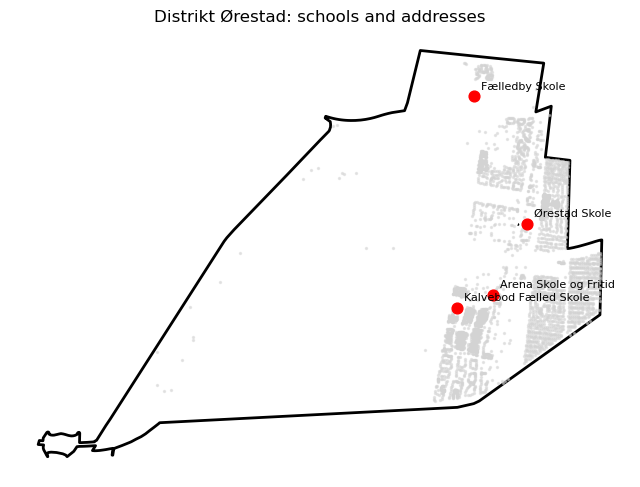

In [36]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot district boundary from its geometry series
district_poly.geometry.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=2
)

# Plot address points from the active geometry column directly
district_addresses["address_geometry"].plot(
    ax=ax,
    color="lightgrey",
    markersize=2,
    alpha=0.5
)

# Plot school points from the school point geometry
district_schools_points["school_point"].plot(
    ax=ax,
    color="red",
    markersize=60
)

for _, row in district_schools_points.iterrows():
    ax.annotate(
        row["school_name"],
        (row["school_point"].x, row["school_point"].y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title("Distrikt Ørestad: schools and addresses")
ax.set_axis_off()
plt.show()

## Build the Voronoi tessellation from the school points

The Voronoi tessellation divides space into cells around the school points.

Each cell represents the area that is closest to one school in straight-line distance.

After building the Voronoi diagram, I clip the cells to the official Ørestad district boundary.

In [37]:
school_points = MultiPoint(list(district_schools_points["school_point"]))
vor = voronoi_diagram(school_points, envelope=district_poly.geometry.iloc[0])

vor_polys = gpd.GeoDataFrame(
    geometry=[geom for geom in vor.geoms if geom is not None and not geom.is_empty],
    crs="EPSG:25832"
)

print("Number of raw Voronoi cells:", len(vor_polys))

Number of raw Voronoi cells: 4


/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/constructive.py:963: RuntimeWarning: invalid value encountered in voronoi_polygons
  return lib.voronoi_polygons(geometry, tolerance, extend_to, only_edges, **kwargs)


## Clean the district and Voronoi geometries before clipping

Before clipping the Voronoi cells to the official Ørestad district boundary, I clean the geometries.

Small geometry issues can sometimes appear after spatial operations, so this step helps make the clipping more stable.

I then intersect the Voronoi cells with the district polygon so that the final cells only cover the official district area.

In [38]:
district_poly_clean = district_poly.copy()
district_poly_clean["geometry"] = district_poly_clean.geometry.buffer(0)

vor_polys["geometry"] = vor_polys.geometry.buffer(0)

vor_clipped = gpd.overlay(vor_polys, district_poly_clean, how="intersection")
vor_clipped = vor_clipped.loc[~vor_clipped.geometry.is_empty].copy()
vor_clipped = vor_clipped.reset_index(drop=True)

print("Number of clipped Voronoi cells:", len(vor_clipped))

Number of clipped Voronoi cells: 4


/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


## Assign each clipped Voronoi cell to the nearest school

After clipping, I label each Voronoi cell with the nearest school point.

This makes it possible to colour the Voronoi cells by school name in the final figure, so the allocation areas can be interpreted more easily.

In [39]:
vor_clipped["cell_id"] = vor_clipped.index
district_schools_points["school_id"] = district_schools_points.index

vor_clipped["cell_centroid"] = vor_clipped.geometry.centroid

cell_centroids = gpd.GeoDataFrame(
    vor_clipped[["cell_id"]].copy(),
    geometry=vor_clipped["cell_centroid"],
    crs="EPSG:25832"
)

cell_to_school = gpd.sjoin_nearest(
    cell_centroids,
    district_schools_points[["school_id", "school_name", "school_point"]],
    how="left",
    distance_col="dist_to_school"
)

vor_clipped = vor_clipped.merge(
    cell_to_school[["cell_id", "school_id", "school_name"]],
    on="cell_id",
    how="left"
)

vor_clipped = vor_clipped.drop(columns="cell_centroid")
vor_clipped.head()

,district_code,district_name,geometry,cell_id,school_id,school_name
0,281474,Distrikt Ørestad,"POLYGON ((724305.344 6171096.851, 723004.145 6...",0,57,Fælledby Skole
1,281474,Distrikt Ørestad,"POLYGON ((724305.344 6171096.851, 724687.189 6...",1,52,Kalvebod Fælled Skole
2,281474,Distrikt Ørestad,"POLYGON ((724687.189 6170777.561, 724305.344 6...",2,49,Ørestad Skole
3,281474,Distrikt Ørestad,"POLYGON ((724687.189 6170777.561, 726144.395 6...",3,56,Arena Skole og Fritid


## Final map of Voronoi school allocation in Distrikt Ørestad

This figure shows the nearest-school allocation visually inside Distrikt Ørestad.

Each coloured polygon represents the area that is closest to one of the schools in straight-line distance, restricted to the official district boundary.

The grey points are the addresses in the district, and the red points are the school locations.

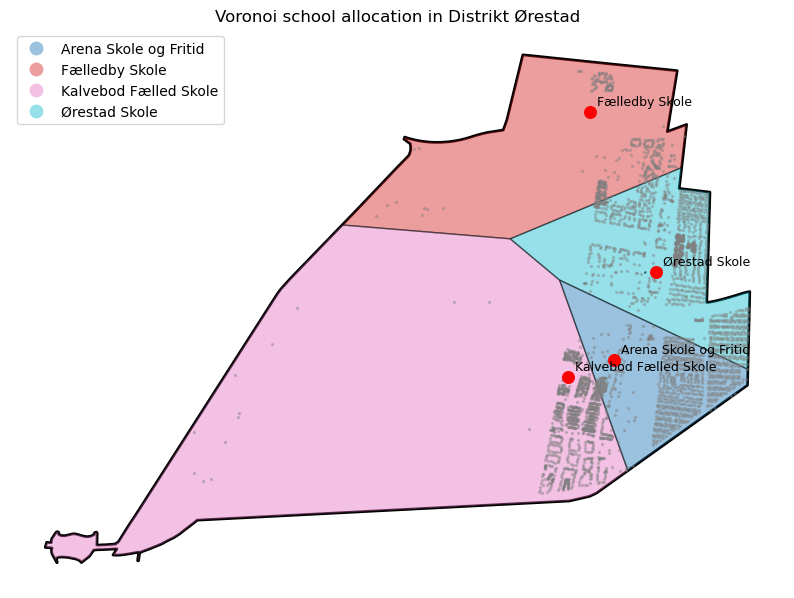

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))

district_poly.geometry.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=2
)

vor_clipped.plot(
    ax=ax,
    column="school_name",
    alpha=0.45,
    legend=True,
    edgecolor="black"
)

district_addresses["address_geometry"].plot(
    ax=ax,
    color="grey",
    markersize=2,
    alpha=0.35
)

district_schools_points["school_point"].plot(
    ax=ax,
    color="red",
    markersize=70
)

for _, row in district_schools_points.iterrows():
    ax.annotate(
        row["school_name"],
        (row["school_point"].x, row["school_point"].y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title("Voronoi school allocation in Distrikt Ørestad")
ax.set_axis_off()
plt.show()

## Animation of the Voronoi allocation

This animation shows how the Voronoi allocation emerges as school points are added one by one in Distrikt Ørestad

In [45]:
schools_anim = district_schools_points.copy().reset_index(drop=True)

district_poly_clean = district_poly.copy()
district_poly_clean["geometry"] = district_poly_clean.geometry.buffer(0)

precomputed_frames = []

for n in range(1, len(schools_anim) + 1):
    current_schools = schools_anim.iloc[:n].copy()

    vor_clipped = None

    if len(current_schools) >= 2:
        school_points = MultiPoint(list(current_schools["school_point"]))

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="invalid value encountered in voronoi_polygons")
            warnings.filterwarnings("ignore", message="invalid value encountered in intersection")

            vor = voronoi_diagram(
                school_points,
                envelope=district_poly_clean.geometry.iloc[0]
            )

            vor_polys = gpd.GeoDataFrame(
                geometry=[geom for geom in vor.geoms if geom is not None and not geom.is_empty],
                crs="EPSG:25832"
            )

            vor_polys["geometry"] = vor_polys.geometry.buffer(0)

            vor_clipped = gpd.overlay(vor_polys, district_poly_clean, how="intersection")
            vor_clipped = vor_clipped.loc[
                vor_clipped.geometry.notna() & (~vor_clipped.geometry.is_empty)
            ].copy()
            vor_clipped["geometry"] = vor_clipped.geometry.buffer(0)
            vor_clipped = vor_clipped.reset_index(drop=True)

    precomputed_frames.append({
        "schools": current_schools,
        "vor_clipped": vor_clipped
    })

In [46]:
fig, ax = plt.subplots(figsize=(8, 8))

def draw_frame(i):
    ax.clear()

    frame = precomputed_frames[i]
    current_schools = frame["schools"]
    vor_clipped = frame["vor_clipped"]

    district_poly.geometry.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=2
    )

    district_addresses["address_geometry"].plot(
        ax=ax,
        color="lightgrey",
        markersize=2,
        alpha=0.35
    )

    if vor_clipped is not None and len(vor_clipped) > 0:
        vor_clipped.plot(
            ax=ax,
            alpha=0.35,
            edgecolor="black"
        )

    current_schools["school_point"].plot(
        ax=ax,
        color="red",
        markersize=70
    )

    for _, row in current_schools.iterrows():
        ax.annotate(
            row["school_name"],
            (row["school_point"].x, row["school_point"].y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

    ax.set_title(f"Voronoi allocation in Ørestad: {len(current_schools)} school(s)")
    ax.set_axis_off()

anim = FuncAnimation(fig, draw_frame, frames=len(precomputed_frames), repeat=True)
plt.close(fig)
anim

In [47]:
anim.save(
    "../outputs/orestad_voronoi_animation.gif",
    writer=PillowWriter(fps=1)
)

<Figure size 640x480 with 0 Axes>

In [ ]:
from IPython.display import Image

Image(filename="../outputs/orestad_voronoi_animation.gif")

## Smoother animated Voronoi allocation

This animation uses more frames than before by adding small transition steps between the school-allocation stages.

The Voronoi cells are also coloured by school so the different nearest-school areas are easier to distinguish.

In [49]:
school_colors = {
    "Ørestad Skole": "#4C78A8",
    "Kalvebod Fælled Skole": "#F58518",
    "Arena Skole og Fritid": "#54A24B",
    "Fælledby Skole": "#E45756"
}

In [50]:
schools_anim = district_schools_points.copy().reset_index(drop=True)

district_poly_clean = district_poly.copy()
district_poly_clean["geometry"] = district_poly_clean.geometry.buffer(0)

stage_data = []

for n in range(1, len(schools_anim) + 1):
    current_schools = schools_anim.iloc[:n].copy()
    vor_clipped = None

    if len(current_schools) >= 2:
        school_points = MultiPoint(list(current_schools["school_point"]))

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="invalid value encountered in voronoi_polygons")
            warnings.filterwarnings("ignore", message="invalid value encountered in intersection")

            vor = voronoi_diagram(
                school_points,
                envelope=district_poly_clean.geometry.iloc[0]
            )

            vor_polys = gpd.GeoDataFrame(
                geometry=[geom for geom in vor.geoms if geom is not None and not geom.is_empty],
                crs="EPSG:25832"
            )

            vor_polys["geometry"] = vor_polys.geometry.buffer(0)

            vor_clipped = gpd.overlay(vor_polys, district_poly_clean, how="intersection")
            vor_clipped = vor_clipped.loc[
                vor_clipped.geometry.notna() & (~vor_clipped.geometry.is_empty)
            ].copy()

            vor_clipped["geometry"] = vor_clipped.geometry.buffer(0)
            vor_clipped = vor_clipped.reset_index(drop=True)

            
            vor_clipped["cell_id"] = vor_clipped.index
            current_schools = current_schools.copy()
            current_schools["school_id"] = current_schools.index

            vor_clipped["cell_centroid"] = vor_clipped.geometry.centroid

            cell_centroids = gpd.GeoDataFrame(
                vor_clipped[["cell_id"]].copy(),
                geometry=vor_clipped["cell_centroid"],
                crs="EPSG:25832"
            )

            cell_to_school = gpd.sjoin_nearest(
                cell_centroids,
                current_schools[["school_id", "school_name", "school_point"]],
                how="left",
                distance_col="dist_to_school"
            )

            vor_clipped = vor_clipped.merge(
                cell_to_school[["cell_id", "school_id", "school_name"]],
                on="cell_id",
                how="left"
            )

            vor_clipped = vor_clipped.drop(columns="cell_centroid")

    stage_data.append({
        "schools": current_schools,
        "vor_clipped": vor_clipped
    })

In [51]:
frames_per_stage = 8

animation_frames = []

for stage_idx, stage in enumerate(stage_data):
    for subframe in range(frames_per_stage):
        progress = (subframe + 1) / frames_per_stage

        animation_frames.append({
            "stage_idx": stage_idx,
            "progress": progress,
            "schools": stage["schools"],
            "vor_clipped": stage["vor_clipped"]
        })

print("Total frames:", len(animation_frames))

Total frames: 32


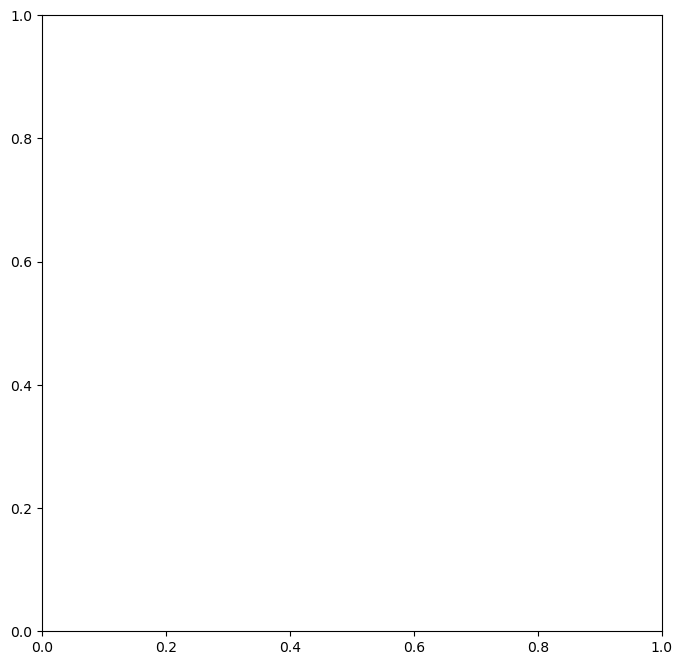

In [52]:
fig, ax = plt.subplots(figsize=(8, 8))

def draw_frame(i):
    ax.clear()

    frame = animation_frames[i]
    current_schools = frame["schools"]
    vor_clipped = frame["vor_clipped"]
    progress = frame["progress"]

    # base layers
    district_poly.geometry.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=2
    )

    district_addresses["address_geometry"].plot(
        ax=ax,
        color="lightgrey",
        markersize=2,
        alpha=0.25
    )

    
    if vor_clipped is not None and len(vor_clipped) > 0:
        for school_name, color in school_colors.items():
            subset = vor_clipped[vor_clipped["school_name"] == school_name]
            if len(subset) > 0:
                subset.plot(
                    ax=ax,
                    color=color,
                    alpha=0.15 + 0.35 * progress,
                    edgecolor="black",
                    linewidth=0.8
                )

    # school points
    current_schools["school_point"].plot(
        ax=ax,
        color="red",
        markersize=70
    )

    for _, row in current_schools.iterrows():
        ax.annotate(
            row["school_name"],
            (row["school_point"].x, row["school_point"].y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

    ax.set_title(
        f"Voronoi allocation in Ørestad: {len(current_schools)} school(s)"
    )
    ax.set_axis_off()

In [53]:
anim = FuncAnimation(
    fig,
    draw_frame,
    frames=len(animation_frames),
    repeat=True
)

plt.close(fig)
anim

In [54]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="invalid value encountered in voronoi_polygons")
    warnings.filterwarnings("ignore", message="invalid value encountered in intersection")

    anim.save(
        "../outputs/orestad_voronoi_animation_colored.gif",
        writer=PillowWriter(fps=4)
    )

<Figure size 640x480 with 0 Axes>